### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model, utils, callbacks, optimizers, metrics

In [76]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [18]:
from wordcloud import WordCloud

### Step 2: Constant

In [50]:
DATA_PATH = './data/swiggy.csv'
LABEL_LIST = [0, 1]
MAX_FEATURES = 5000
MAX_LENGTH = 200
EPOCHS = 20
BATCH_SIZE = 64

### Step 3: Load Data

In [5]:
df = pd.read_csv(DATA_PATH)

In [6]:
df.shape

(8000, 10)

In [7]:
df.head()

,ID,Area,City,Restaurant Price,Avg Rating,Total Rating,Food Item,Food Type,Delivery Time,Review
0,1,Suburb,Ahmedabad,600,4.2,6198,Sushi,Fast Food,30-40 min,"Good, but nothing extraordinary."
1,2,Business District,Pune,200,4.7,4865,Pepperoni Pizza,Non-Vegetarian,50-60 min,"Good, but nothing extraordinary."
2,3,Suburb,Bangalore,600,4.7,2095,Waffles,Fast Food,50-60 min,Late delivery ruined it.
3,4,Business District,Mumbai,900,4.0,6639,Sushi,Vegetarian,50-60 min,Best meal I've had in a while!
4,5,Tech Park,Mumbai,200,4.7,6926,Spring Rolls,Gluten-Free,20-30 min,Mediocre experience.


### Step 4: Exploaring Data

#### Basic Info

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,8000.0,4000.5000,2309.545410,1.0,2000.75,4000.5,6000.25,8000.0
Restaurant Price,8000.0,544.5875,287.968871,100.0,300.00,500.0,800.00,1000.0
Avg Rating,8000.0,4.1299,0.645791,3.0,3.50,4.2,4.70,5.0
Total Rating,8000.0,4979.9775,2877.285148,51.0,2476.00,4989.5,7498.00,10000.0


In [9]:
feature_info = pd.DataFrame(
    {
        'null': df.isna().sum(),
        'null(%)': round(df.isna().sum()/len(df), 3),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [10]:
feature_info

,null,null(%),unique,type
ID,0,0.0,8000,int64
Area,0,0.0,7,object
City,0,0.0,8,object
Restaurant Price,0,0.0,10,int64
Avg Rating,0,0.0,7,float64
Total Rating,0,0.0,5537,int64
Food Item,0,0.0,50,object
Food Type,0,0.0,6,object
Delivery Time,0,0.0,4,object
Review,0,0.0,27,object


#### Build Target

In [11]:
df['sentiment'] = df['Avg Rating'].map(lambda x: 1 if x>3.5 else 0)

#### Target Distribution

In [12]:
temp = df['sentiment'].value_counts()

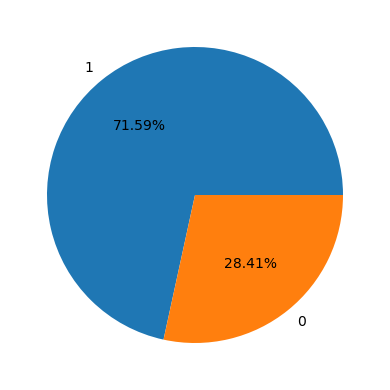

In [13]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index
)
plt.tight_layout()

### Step 5: Preparing Data

#### Handling Missing Value

In [14]:
df.dropna(inplace=True)

#### Text Cleaning

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

In [17]:
df['Review'] = df['Review'].map(clean_text)

#### Word Cloud

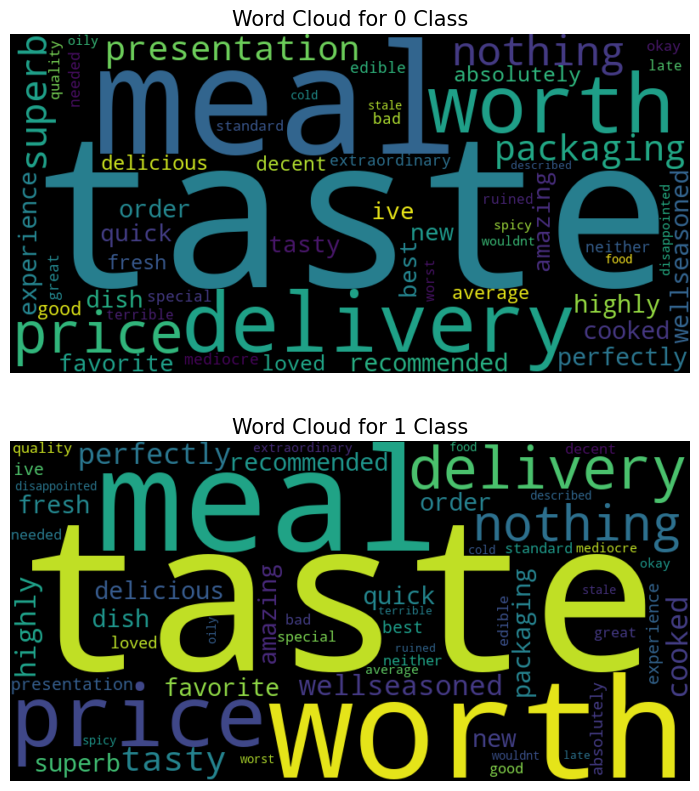

In [21]:
plt.figure(figsize=(10, 15))
for i in range(len(LABEL_LIST)):
    temp = df[df['sentiment']==i]
    corpus = " ".join(temp['Review'])
    wc = WordCloud(
        max_words=100, 
        width=800, 
        height=400,
        collocations=False
    ).generate(corpus)
    plt.subplot(3, 1, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {LABEL_LIST[i]} Class", fontsize=15)

#### Tokenizer

In [28]:
tokenizer = Tokenizer(num_words=MAX_FEATURES)

In [29]:
tokenizer.fit_on_texts(df['Review'])

In [30]:
X = pad_sequences(
    tokenizer.texts_to_sequences(
        df['Review']
    ), maxlen=MAX_LENGTH
)

In [32]:
y = df['sentiment'].values

#### Split Data

In [33]:
X_train, X_value, y_train, y_value = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

In [34]:
X_value, X_test, y_value, y_test = train_test_split(
    X_value,
    y_value,
    test_size=0.5,
    random_state=42
)

### Step 6: Model Development

#### Build Model

In [61]:
inputs = layers.Input(shape=(MAX_LENGTH,))

In [62]:
x = layers.Embedding(input_dim=MAX_FEATURES, output_dim=32, input_length=MAX_LENGTH)(inputs)
x = layers.SimpleRNN(64, activation='tanh', return_sequences=False)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

In [63]:
model = Model(inputs, outputs)

In [69]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_2 (Embedding)              │ (None, 200, 32)             │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 64)                  │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 498,821 (1.90 MB)

 Trainable params: 166,273 (649.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 332,548 (1.27 MB)

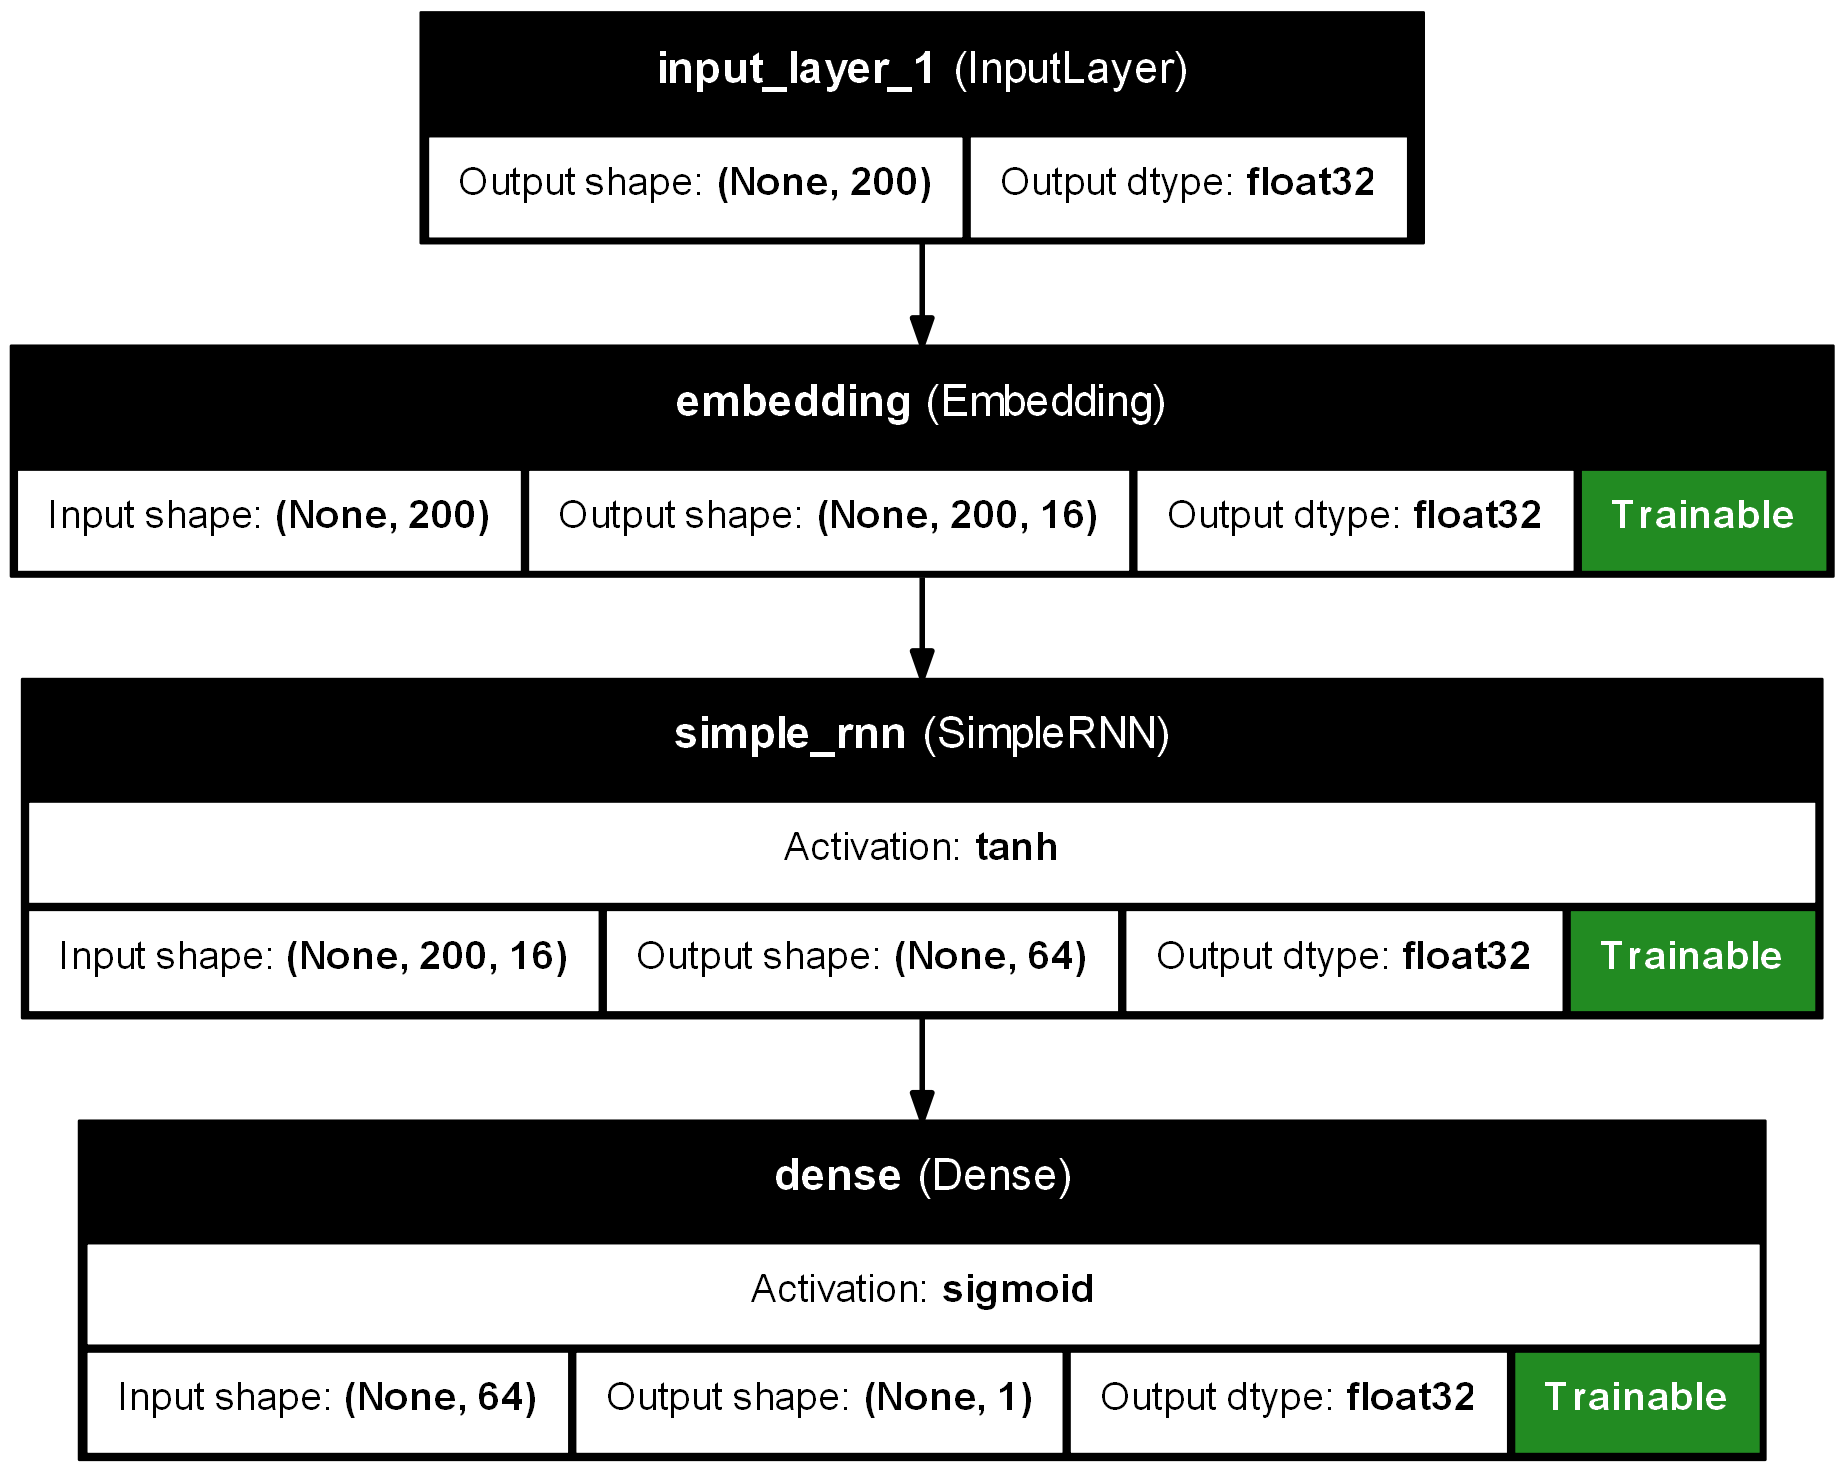

In [44]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    show_layer_activations=True,
    show_trainable=True,
)

#### Compile Model

In [64]:
optimizer = optimizers.Adam(clipnorm=1.0)

In [65]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [66]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [67]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [68]:
history = model.fit(
    X_train, 
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_value, y_value),
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7131 - loss: 0.6028 - val_accuracy: 0.7113 - val_loss: 0.6048
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7140 - loss: 0.6004 - val_accuracy: 0.7113 - val_loss: 0.6046
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7140 - loss: 0.5989 - val_accuracy: 0.7113 - val_loss: 0.6051
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7140 - loss: 0.5998 - val_accuracy: 0.7113 - val_loss: 0.6040
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7140 - loss: 0.5977 - val_accuracy: 0.7113 - val_loss: 0.6044
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7140 - loss: 0.5975 - val_accuracy: 0.7113 - val_loss: 0.6045
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7140 - loss: 0.5979 - val_accuracy: 0.7113 - val_loss: 0.6060
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7140 - loss: 0.5982 - val_accuracy: 0.7113 - v

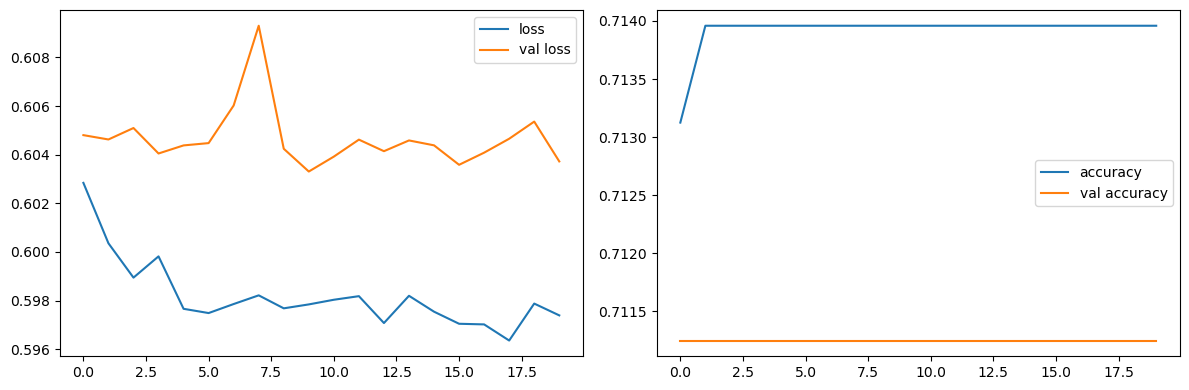

In [73]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [74]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(acc, 3)}')

test loss: 0.59, test accuracy: 0.726


In [75]:
test_pred = model.predict(X_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [85]:
confusion_matrix = metrics.confusion_matrix(y_test, np.array(test_pred>=0.5).astype(np.int8).reshape(-1))

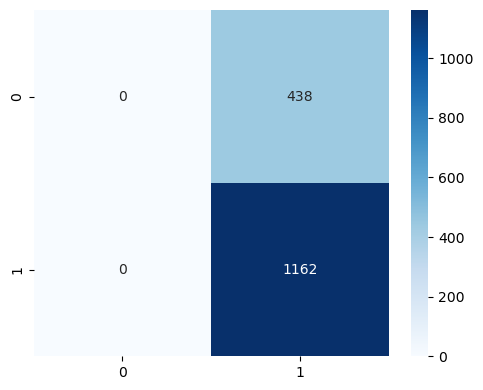

In [88]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.tight_layout()

In [90]:
print(metrics.classification_report(y_test, np.array(test_pred>=0.5).astype(np.int8).reshape(-1)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       438
           1       0.73      1.00      0.84      1162

    accuracy                           0.73      1600
   macro avg       0.36      0.50      0.42      1600
weighted avg       0.53      0.73      0.61      1600



#### Predict Model

In [91]:
def predict_sentiment(review_text):
    text = clean_text(review_text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH)

    prediction = model.predict(padded)[0][0]
    return f"{'Positive' if prediction >= 0.5 else 'Negative'} (Probability: {prediction:.2f})"

In [92]:
sample_review = "The food was great."
print(f"Review: {sample_review}")
print(f"Sentiment: {predict_sentiment(sample_review)}")

Review: The food was great.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Sentiment: Positive (Probability: 0.70)
